<a href="https://colab.research.google.com/github/Laurasgrv-colab/PRe/blob/main/CaseStudy3_bayesian_logistic_regression_SOUL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study : Bayesian logistic regression via SOUL

This notebook includes my implementation of the SOUL algorithm and its result comparison to the Bayesian logistic regression example in Section 3.1 of [Particle algorithms for maximum likelihood training of latent variable models](https://juankuntz.github.io/publication/parem/).  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#@title Load modules.

# Install the wget package on Colab (if running the notebook locally,
# comment the following line out).
!pip install wget

# OS and wget to load dataset.
import os
import wget
from scipy.stats import norm


  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=26bb37de667d6965c9da04215d6b62be72f78b8a6764773a1268fc101b728d46
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


We load the same dataset in order to compare results and verify the correctness of our function.

In [ ]:
#@title Load and normalize the Wisconsin Breast Cancer dataset.

# Fetch dataset from repository:
wget.download('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data')

# Load dataset:
dataset = np.loadtxt('breast-cancer-wisconsin.data', dtype=str, delimiter=',')

# Delete local copy of dataset to avoid duplicates with multiple notebook runs:
os.remove('breast-cancer-wisconsin.data')

# Remove datapoints with missing attributes and change dtype to float:
dataset = dataset[~(dataset == '?').any(axis=1), :].astype(float)

# Extract features and labels, and normalize features:
features = np.array(dataset[:, 1:10] - dataset[:, 1:10].mean(0))
features = features/features.std(0)
labels = np.array([(dataset[:, 10]-2)/2]).transpose()

This is my SOUL function.

In [ ]:
def soul(log_p_grad_x, th0, x0_M, y_l, y_f, T, M, B, delta_step, gamma_step):
  """
    Stochastic Optimisation via Unadjusted Langevin (SOUL).

    Parameters:
    - log_p_grad_x: Function returning grad_x log p(th, X, y). Shape matches X.
    - log_p_grad_th: Function returning grad_theta log p(th, X, y). Shape matches theta.
    - th_0: Initial parameters
    - x0_M: Initial latent variables from the previous step
    - y: Observed data
    - T: Number of outer optimization steps
    - M: Number of Langevin steps
    - B: Burn-in steps
    - delta_step: Step size for theta update
    - gamma_step: Langevin step size
    """
  th = np.copy(th0)
  x_t = np.copy(x0_M[:, 0:1]).reshape(D,1) # shape (D,1) (instead of (D,)) - keeps the column dimension

  x_values = np.array(x0_M)
  th_list = [th0]
  for t in range(1, T+1):

    # ULA steps
    for m in range(1, M+1):
      grad_x = log_p_grad_x(th, x_t, y_l, y_f)
      Z_k = np.random.normal(0.0, 1.0, x_t.shape) # Force size

      # Compute new x
      x_t += gamma_step * grad_x + np.sqrt(2.0 * gamma_step) * Z_k
      x_values = np.append(x_values, np.copy(x_t), axis=1) # Store new position

    burnin_x_samples = x_values[:, -(M-B):] # Shape (D, M-B)

    # Compute new theta
    avg_grad_th = np.zeros_like(th) # th is (1,1), so avg_grad_th is (1,1)

    # Iterate over particles (columns) instead of feature dimensions (rows)
    for idx in range(M-B):
      x_m_burnin = burnin_x_samples[:, idx:idx+1] # Shape (D,1)
      # (x_m_burnin - th) will broadcast to (D, 1).
      # We first sum only along D with .sum(0), then average over M-B.
      avg_grad_th += ((x_m_burnin - th).sum(0) / 5)

    th = th + delta_step * avg_grad_th /(M-B) # Update theta
    th_list.append(np.copy(th)) # Store new theta

  return th_list, x_values

And this is the gradient function specific to the problem.

In [ ]:
def log_p_grad_x(th, x, y_l, y_f):
  s = 1/(1+np.exp(- np.matmul(y_f, x)))
  return np.matmul((y_l-s).transpose(), y_f).transpose() - (x-th)/5


This is the SOUL function produced by Kuntz et al. for their *Particle algorithms for maximum likelihood training of latent variable models* (2023) article, that can be found [here](https://github.com/juankuntz/ParEM/blob/main/README.md).
We will use this as a 'control' to compare our results and the performance of our SOUL function.

In [ ]:
def soul_ctrl(l, f, h, K, N, th, X):
    for k in range(K):
        # Run ULA chain:
        for n in range(N):
            Xkn = X[:, -1].reshape(D, 1)  # Extract current particle position.
            # Take a step:
            Xknp1 = (Xkn + h*grad_x(th[k], Xkn, l, f)
                          + np.sqrt(2*h)*np.random.normal(0, 1, (D, 1)))
            X = np.append(X, Xknp1, axis=1)  # Store new particle position.
        th = np.append(th, th[k] + h*ave_grad_th(th[k], X[:, -N:]))  # Update theta.
    return th, X

    # Auxiliary functions.

def ave_grad_th(th, x):
    """Returns theta-gradient of log density averaged over particle cloud."""
    return ((x-th).sum(0)).mean()/5

def grad_x(th, x, l, f):
    """Returns x-gradient of log density vectorized over particles."""
    s = 1/(1+np.exp(- np.matmul(f, x)))
    return np.matmul((l-s).transpose(), f).transpose() - (x-th)/5

# Figure 3a

Let's run the algorithm on 80/20 split of the data and plot the results.

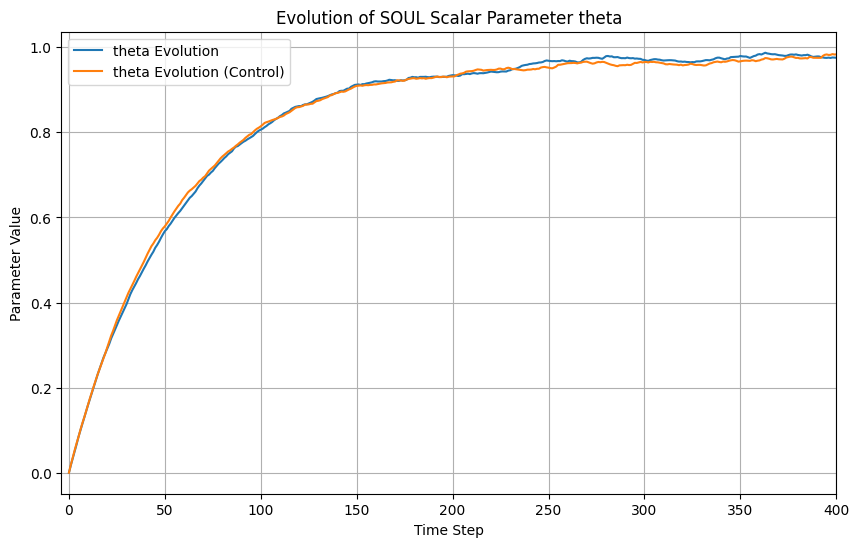

In [ ]:
# Split data into 80/20 training and testing sets:
from sklearn.model_selection import train_test_split
ftrain, ftest, ltrain, ltest = train_test_split(features, labels, test_size=0.2,
                                                random_state=0)

# Set approximation parameters as in our reference paper:
delta_step = 1e-2 # Step-size, same for ULA and Langevin in this case.
gamma_step = 1e-2
T = 400  # Number of steps.
M = 100  # Number of particles.
B = 0 # There is no burn-in in this example.

# Initialize parameter estimates and particle cloud, all at zero:
D = features[0, :].size  # Dimension of latent space.
th0 = np.array([0.0])  # Parameter estimate, initialized as a (1,1) float array (scalar).
x0 = np.zeros((D, M))  # Particle cloud.

# Run algorithm:
th_soul, x_soul = soul(log_p_grad_x, th0, x0, ltrain, ftrain, T, M, B, delta_step, gamma_step)

# Compare to the control function
th_ctrl, x_ctrl = soul_ctrl(ltrain, ftrain, delta_step, T, M, np.array([[0]]), x0)

# Plot the results
plt.figure(figsize=(10, 6))

plt.plot(th_soul, label='theta Evolution')
plt.plot(th_ctrl, label='theta Evolution (Control)')
plt.xlim([-T/100, T])
plt.xlabel('Time Step')
plt.ylabel('Parameter Value')
plt.title('Evolution of SOUL Scalar Parameter theta')
plt.legend()
plt.grid(True)
plt.show()

We obtain the same allure as in the paper. Small differences are due to the randomness within each run.

# Figure 3b

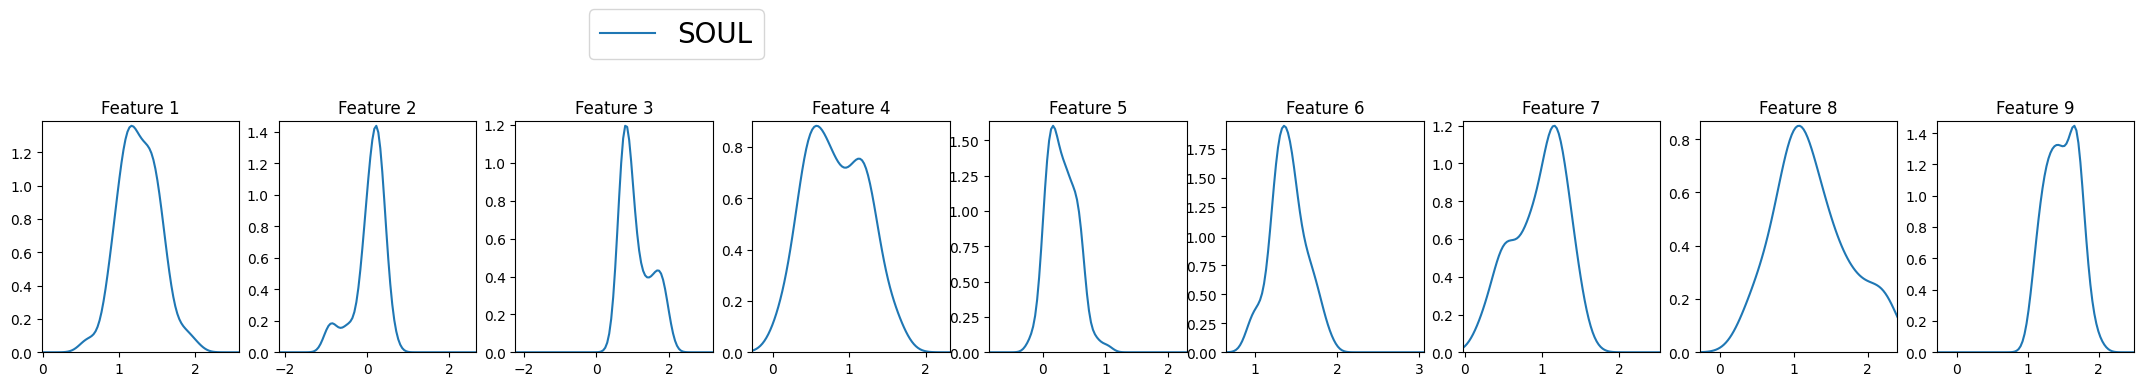

In [ ]:
# Extract final particle clouds X^{1:N}_K:
q_soul = x_soul[:, -M:]

# Generate and plot KDEs:
from scipy import stats  # stats to generate KDEs.
fig = plt.figure(figsize=(27,3), dpi= 100)

kde_r_list=[np.float64(2.58115862700272), np.float64(2.6487090518790377),
            np.float64(3.209504392076402), np.float64(2.3150004182323594),
            np.float64(2.2982599337403675), np.float64(3.050490617053107),
            np.float64(2.5301136977877774), np.float64(2.401086429683187),
            np.float64(2.498822615845701)]
kde_l_list=[np.float64(-0.015738804057094602), np.float64(-2.15085088023593),
            np.float64(-2.2304838689735194), np.float64(-0.2640190516743613),
            np.float64(-0.8586621768891025), np.float64(0.6472855588865127),
            np.float64(-0.019397450827125517), np.float64(-0.2697351136842945),
            np.float64(-0.28102164581791156)]

for i in range(D):
    # Generate KDEs for ith entry of the final particle cloud X^{1:N}_K:
    kde_min = kde_l_list[i]
    kde_max = kde_r_list[i]
    xaxis = np.linspace(kde_min, kde_max, num=100)

    kde_soul = stats.gaussian_kde(q_soul[i, :])(xaxis)

    # Plot KDEs:
    plt.subplot(1, D, i+1)
    plt.plot(xaxis, kde_soul, label='SOUL')
    plt.title('Feature ' + str(i+1))
    plt.ylim([0, 1.02*np.max([kde_soul])])
    plt.xlim([kde_min, kde_max])


handles, figlabels = plt.gca().get_legend_handles_labels()
fig.legend(handles, figlabels, ncol=4, bbox_to_anchor=(0.36,1.3),
           loc="upper center",fontsize=20)
plt.subplots_adjust(hspace=0.6)

Again, the allure is similar to that in the paper. However, since randomness plays a more important role here, we will average out 20 runs to make a better comparison.

# Average Figure 3b

In [ ]:
# Run the code 20 times and compute the averages

th_avg = np.zeros((T + 1, 1))
x_avg = np.zeros((D, M))


for i in range(30):
  th_soul_full, x_soul_full = soul(log_p_grad_x, th0, x0, ltrain, ftrain, T, M, B, delta_step, gamma_step)
  # Convert th_soul_list to a numpy array for addition
  th_avg += np.array(th_soul_full)
  # Only take the last M particles for x_avg
  x_avg += x_soul_full[:, -M:]

th_avg = th_avg/30
x_avg = x_avg/30

In [ ]:
th_avg_cntrl = np.zeros((T + 1, 1))
x_avg_cntrl = np.zeros((D, M))

for i in range(30):
  th_soul_cntrl, x_soul_cntrl = soul_ctrl(ltrain, ftrain, delta_step, T, M, np.array([[0]]), x0)
  # Convert th_soul_cntrl to a 2D numpy array with shape (T+1, 1) for addition
  th_avg_cntrl += th_soul_cntrl.reshape(-1, 1)
  # Only take the last M particles for x_avg_cntrl
  x_avg_cntrl += x_soul_cntrl[:, -M:]

th_avg_cntrl = th_avg_cntrl/30
x_avg_cntrl = x_avg_cntrl/30

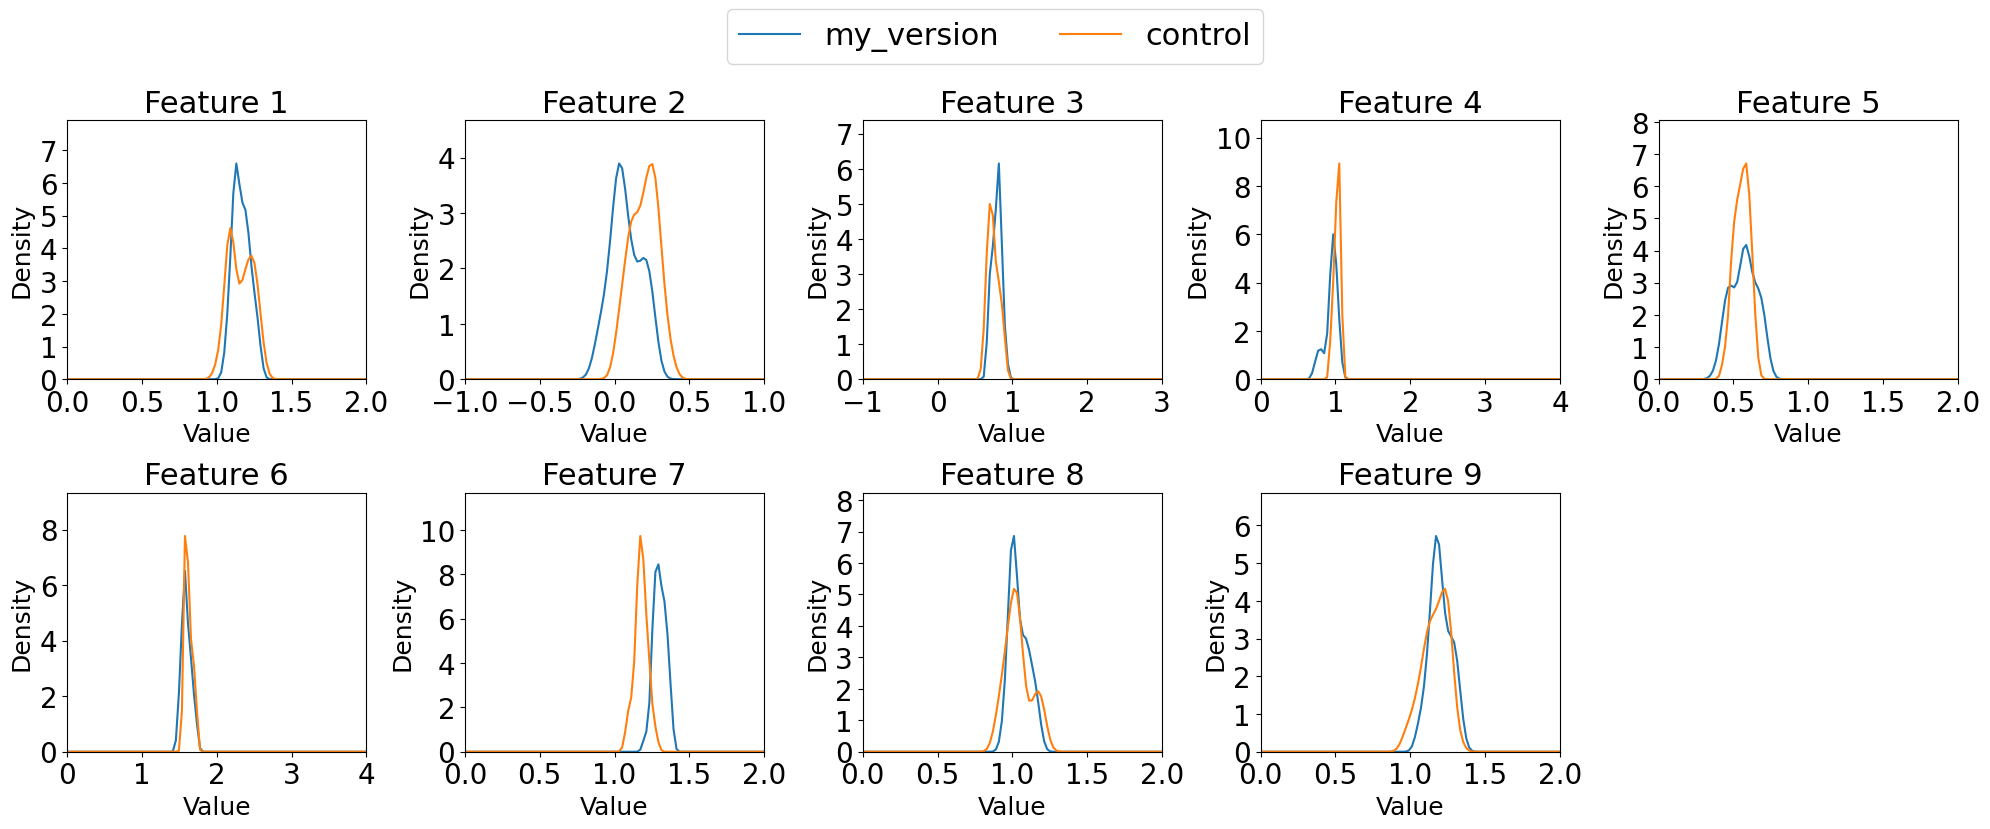

In [43]:
# Plot both averages

q_soul_avg = x_avg[:, -M:]
q_soul_avg_cntrl = x_avg_cntrl[:, -M:]

# Generate and plot KDEs:
from scipy import stats  # stats to generate KDEs.
import math # For ceil function

# Calculate number of columns for the subplots
num_cols = math.ceil(D / 2)

fig = plt.figure(figsize=(20, 8), dpi= 100) # Adjusted figure size for two rows

# These are based on previous plots.
# The exact values are arbitrary but allow us to compare easily the plots.
kde_r_list=[2.0, 1.0, 3.0, 4.0, 2.0, 4.0, 2.0, 2.0, 2.0]
kde_l_list=[0.0, -1.0, -1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

for i in range(D):
    # Generate KDEs for ith entry of the final particle cloud X^{1:N}_K:
    kde_min = kde_l_list[i]
    kde_max = kde_r_list[i]
    xaxis = np.linspace(kde_min, kde_max, num=100)

    kde_soul_avg = stats.gaussian_kde(q_soul_avg[i, :])(xaxis)
    kde_soul_avg_cntrl = stats.gaussian_kde(q_soul_avg_cntrl[i, :])(xaxis)

    # Plot KDEs:
    plt.subplot(2, num_cols, i+1)
    plt.plot(xaxis, kde_soul_avg, label='my_version' )
    plt.plot(xaxis, kde_soul_avg_cntrl, label='control')
    plt.title('Feature ' + str(i+1), fontsize=22)
    plt.ylim([0, 1.2*np.max([kde_soul_avg, kde_soul_avg_cntrl])])
    plt.xlim([kde_min, kde_max])
    plt.xlabel('Value', fontsize=18)
    plt.ylabel('Density', fontsize=18)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

handles, figlabels = plt.gca().get_legend_handles_labels()
fig.legend(handles, figlabels, ncol=4, bbox_to_anchor=(0.5, 1.05), # Adjusted legend position
           loc="upper center",fontsize=22)
plt.subplots_adjust(hspace=0.6)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to prevent title/legend overlap

# Figure 3c


In [ ]:
th0 = np.array([10.]) # Float
x0 = 10*np.ones((D, M))


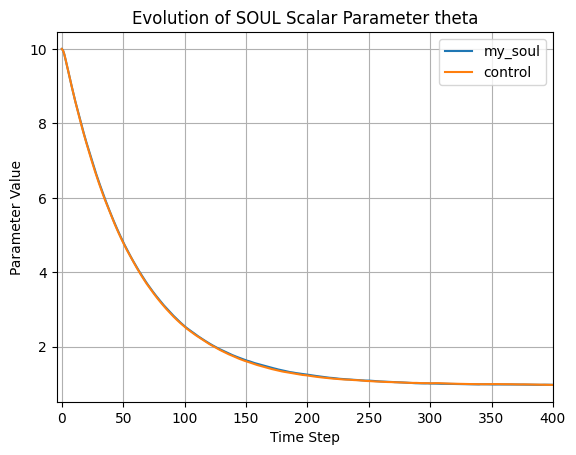

In [ ]:
# Re-run algorithm:
th_soul, x_soul = soul(log_p_grad_x, th0, x0, ltrain, ftrain, T, M, B, delta_step, gamma_step)
th_ctrl, x_ctrl = soul_ctrl(ltrain, ftrain, delta_step, T, M, np.array([[10]]), x0)


# Plot parameter estimates:
plt.plot(th_soul, label='my_soul')
plt.plot(th_ctrl, label='control')
plt.xlabel('Time Step')
plt.ylabel('Parameter Value')
plt.title('Evolution of SOUL Scalar Parameter theta')
plt.grid(True)
plt.xlim([-T/100, T])
plt.legend(loc='upper right')

# Performance

We benchmark performance of the algorithms by running them several times. First, we examine their predictive performance, which we evaluate using two metrics: the test error and log pointwise predictive density.